In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
master_df = pd.read_csv('../data/processed/master_delivery_data_clean.csv')
customer_df = pd.read_csv('../data/raw/customers.csv')
event_df = pd.read_csv('../data/raw/delivery_events.csv')
partner_df = pd.read_csv('../data/raw/delivery_partners.csv')
order_df = pd.read_csv('../data/raw/orders.csv')
warehouse_df = pd.read_csv('../data/raw/warehouses.csv')

In [3]:
customer_df.columns.to_list()

['customer_id',
 'name',
 'age',
 'gender',
 'city',
 'customer_type',
 'signup_date']

In [4]:
warehouse_df.columns.to_list()


['warehouse_id',
 'warehouse_name',
 'city',
 'warehouse_type',
 'capacity_units',
 'staff_count',
 'operating_hours']

In [5]:
event_df.columns.to_list()

['event_id',
 'order_id',
 'partner_id',
 'pickup_time',
 'actual_delivery_hours',
 'delivery_status',
 'delay_reason',
 'delivery_attempts',
 'customer_rating']

In [6]:
order_df.columns.to_list()

['order_id',
 'customer_id',
 'order_date',
 'order_time',
 'source_city',
 'destination_city',
 'product_category',
 'product_weight_kg',
 'order_value',
 'distance_km',
 'promised_delivery_hours',
 'warehouse_id',
 'partner_id']

In [7]:
pd.set_option('display.max_columns', None)
master_df.head()


,order_id,customer_id,order_date,order_time,source_city,destination_city,product_category,product_weight_kg,order_value,distance_km,promised_delivery_hours,warehouse_id,partner_id,name,age,gender,city_x,customer_type,signup_date,partner_name,partner_experience_years,vehicle_type,rating,completed_deliveries,partner_city,warehouse_name,city_y,warehouse_type,capacity_units,staff_count,operating_hours,event_id,pickup_time,actual_delivery_hours,delivery_status,delay_reason,delivery_attempts,customer_rating
0,ORD000001,CUST006015,2024-11-25,04:59:28,Bengaluru,Delhi,Sports,0.90,1437.16,225.62,21.01,WH0009,PART0462,Vrinda Roy,61,Male,Delhi,Regular,2025-10-16,Dakshesh Sood,1.7,EV,4.52,2270,Bengaluru,Bengaluru Warehouse 09,Bengaluru,Distribution Center,24080,95,16,EVT000001,04:59:28,17.15,Delivered,NaN,1,4.0
1,ORD000002,CUST004959,2024-04-17,15:41:59,Indore,Delhi,Electronics,0.21,340.44,105.94,22.33,WH0036,PART0275,Vivaan Murty,64,Female,Delhi,Regular,2026-02-19,Manya Krishnamurthy,2.8,Bike,3.65,2660,Indore,Indore Warehouse 36,Indore,Distribution Center,31252,96,16,EVT000002,15:41:59,20.12,Delivered,NaN,1,3.7
2,ORD000003,CUST006266,2025-11-04,23:49:26,Indore,Pune,Sports,0.58,12305.73,657.27,36.23,WH0044,PART0267,Chandran Grewal,41,Female,Pune,Regular,2023-09-10,Janaki Salvi,1.4,EV,4.28,871,Indore,Indore Warehouse 44,Indore,Sorting Hub,50047,192,16,EVT000003,23:49:26,35.20,Delivered,NaN,1,3.8
3,ORD000004,CUST000442,2026-01-12,22:10:34,Indore,Hyderabad,Electronics,0.62,4412.42,797.24,33.97,WH0045,PART0287,Jeevika Pathak,19,Male,Hyderabad,Regular,2024-04-14,Diya Sibal,1.4,Bike,4.66,2168,Indore,Indore Warehouse 45,Indore,Fulfillment Center,77103,173,16,EVT000004,22:10:34,34.32,Delivered,NaN,1,4.5
4,ORD000005,CUST007885,2026-08-01,00:42:35,Delhi,Mumbai,Grocery,1.19,2143.63,844.64,54.02,WH0015,PART0447,Baghyawati Kothari,19,Female,Mumbai,Regular,2024-11-23,Pavani Saraf,2.0,Van,4.49,2165,Delhi,Delhi Warehouse 15,Delhi,Fulfillment Center,60276,211,24,EVT000005,00:42:35,53.06,Delivered,NaN,1,4.8


In [8]:
master_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  50000 non-null  object 
 1   customer_id               50000 non-null  object 
 2   order_date                50000 non-null  object 
 3   order_time                50000 non-null  object 
 4   source_city               50000 non-null  object 
 5   destination_city          50000 non-null  object 
 6   product_category          50000 non-null  object 
 7   product_weight_kg         50000 non-null  float64
 8   order_value               50000 non-null  float64
 9   distance_km               50000 non-null  float64
 10  promised_delivery_hours   50000 non-null  float64
 11  warehouse_id              50000 non-null  object 
 12  partner_id                50000 non-null  object 
 13  name                      50000 non-null  object 
 14  age   

In [9]:
master_df.columns.tolist()

['order_id',
 'customer_id',
 'order_date',
 'order_time',
 'source_city',
 'destination_city',
 'product_category',
 'product_weight_kg',
 'order_value',
 'distance_km',
 'promised_delivery_hours',
 'warehouse_id',
 'partner_id',
 'name',
 'age',
 'gender',
 'city_x',
 'customer_type',
 'signup_date',
 'partner_name',
 'partner_experience_years',
 'vehicle_type',
 'rating',
 'completed_deliveries',
 'partner_city',
 'warehouse_name',
 'city_y',
 'warehouse_type',
 'capacity_units',
 'staff_count',
 'operating_hours',
 'event_id',
 'pickup_time',
 'actual_delivery_hours',
 'delivery_status',
 'delay_reason',
 'delivery_attempts',
 'customer_rating']

In [10]:
master_df.dtypes 

order_id                     object
customer_id                  object
order_date                   object
order_time                   object
source_city                  object
destination_city             object
product_category             object
product_weight_kg           float64
order_value                 float64
distance_km                 float64
promised_delivery_hours     float64
warehouse_id                 object
partner_id                   object
name                         object
age                           int64
gender                       object
city_x                       object
customer_type                object
signup_date                  object
partner_name                 object
partner_experience_years    float64
vehicle_type                 object
rating                      float64
completed_deliveries          int64
partner_city                 object
warehouse_name               object
city_y                       object
warehouse_type              

In [11]:
master_df.isnull().sum()

order_id                        0
customer_id                     0
order_date                      0
order_time                      0
source_city                     0
destination_city                0
product_category                0
product_weight_kg               0
order_value                     0
distance_km                     0
promised_delivery_hours         0
warehouse_id                    0
partner_id                      0
name                            0
age                             0
gender                          0
city_x                          0
customer_type                   0
signup_date                     0
partner_name                    0
partner_experience_years        0
vehicle_type                    0
rating                          0
completed_deliveries            0
partner_city                    0
warehouse_name                  0
city_y                          0
warehouse_type                  0
capacity_units                  0
staff_count   

In [12]:
master_df.duplicated().sum()

np.int64(0)

In [13]:
master_df.shape

(50000, 38)

In [14]:
master_df.describe()

,product_weight_kg,order_value,distance_km,promised_delivery_hours,age,partner_experience_years,rating,completed_deliveries,capacity_units,staff_count,operating_hours,actual_delivery_hours,delivery_attempts,customer_rating
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2.02945,2981.451298,833.625794,42.906001,43.695440,3.823624,4.173303,3842.095180,33229.828560,96.755320,15.692960,44.494268,1.104860,4.023716
std,2.27699,3869.818654,551.735676,21.520007,15.056978,3.674300,0.422711,3833.715005,18743.812405,55.111703,4.560445,25.485042,0.360759,0.725475
min,0.10000,100.000000,2.000000,6.000000,18.000000,0.000000,3.010000,0.000000,9421.000000,26.000000,8.000000,1.000000,1.000000,1.000000
25%,0.74000,920.377500,339.295000,25.817500,31.000000,1.100000,3.870000,1033.000000,19277.000000,52.000000,12.000000,24.970000,1.000000,3.700000
50%,1.35000,1819.880000,827.855000,42.840000,44.000000,2.600000,4.190000,2498.000000,30114.000000,94.000000,16.000000,42.890000,1.000000,4.100000
75%,2.47000,3544.045000,1314.025000,58.712500,57.000000,5.400000,4.490000,5445.000000,41073.000000,121.000000,20.000000,61.820000,1.000000,4.500000
max,50.00000,100000.000000,1800.000000,96.000000,69.000000,15.000000,5.000000,18288.000000,97115.000000,272.000000,24.000000,130.620000,3.000000,5.000000


In [15]:
master_df.head()

,order_id,customer_id,order_date,order_time,source_city,destination_city,product_category,product_weight_kg,order_value,distance_km,promised_delivery_hours,warehouse_id,partner_id,name,age,gender,city_x,customer_type,signup_date,partner_name,partner_experience_years,vehicle_type,rating,completed_deliveries,partner_city,warehouse_name,city_y,warehouse_type,capacity_units,staff_count,operating_hours,event_id,pickup_time,actual_delivery_hours,delivery_status,delay_reason,delivery_attempts,customer_rating
0,ORD000001,CUST006015,2024-11-25,04:59:28,Bengaluru,Delhi,Sports,0.90,1437.16,225.62,21.01,WH0009,PART0462,Vrinda Roy,61,Male,Delhi,Regular,2025-10-16,Dakshesh Sood,1.7,EV,4.52,2270,Bengaluru,Bengaluru Warehouse 09,Bengaluru,Distribution Center,24080,95,16,EVT000001,04:59:28,17.15,Delivered,NaN,1,4.0
1,ORD000002,CUST004959,2024-04-17,15:41:59,Indore,Delhi,Electronics,0.21,340.44,105.94,22.33,WH0036,PART0275,Vivaan Murty,64,Female,Delhi,Regular,2026-02-19,Manya Krishnamurthy,2.8,Bike,3.65,2660,Indore,Indore Warehouse 36,Indore,Distribution Center,31252,96,16,EVT000002,15:41:59,20.12,Delivered,NaN,1,3.7
2,ORD000003,CUST006266,2025-11-04,23:49:26,Indore,Pune,Sports,0.58,12305.73,657.27,36.23,WH0044,PART0267,Chandran Grewal,41,Female,Pune,Regular,2023-09-10,Janaki Salvi,1.4,EV,4.28,871,Indore,Indore Warehouse 44,Indore,Sorting Hub,50047,192,16,EVT000003,23:49:26,35.20,Delivered,NaN,1,3.8
3,ORD000004,CUST000442,2026-01-12,22:10:34,Indore,Hyderabad,Electronics,0.62,4412.42,797.24,33.97,WH0045,PART0287,Jeevika Pathak,19,Male,Hyderabad,Regular,2024-04-14,Diya Sibal,1.4,Bike,4.66,2168,Indore,Indore Warehouse 45,Indore,Fulfillment Center,77103,173,16,EVT000004,22:10:34,34.32,Delivered,NaN,1,4.5
4,ORD000005,CUST007885,2026-08-01,00:42:35,Delhi,Mumbai,Grocery,1.19,2143.63,844.64,54.02,WH0015,PART0447,Baghyawati Kothari,19,Female,Mumbai,Regular,2024-11-23,Pavani Saraf,2.0,Van,4.49,2165,Delhi,Delhi Warehouse 15,Delhi,Fulfillment Center,60276,211,24,EVT000005,00:42:35,53.06,Delivered,NaN,1,4.8


In [16]:
two_col = master_df[['warehouse_name','staff_count']]
two_col.sort_values(by='staff_count', ascending=True)

,warehouse_name,staff_count
30231,Chennai Warehouse 18,26
49945,Chennai Warehouse 18,26
49995,Chennai Warehouse 18,26
25,Chennai Warehouse 18,26
19125,Chennai Warehouse 18,26
...,...,...
17291,Indore Warehouse 24,272
22096,Indore Warehouse 24,272
22051,Indore Warehouse 24,272
35310,Indore Warehouse 24,272


In [17]:
master_df['delivery_status'].value_counts()

delivery_status
Delivered    38242
Delayed       8314
Late          3444
Name: count, dtype: int64

In [18]:
master_df['customer_type'].value_counts()

customer_type
Regular    30219
New        12445
Premium     7336
Name: count, dtype: int64

In [19]:
numerical_col = master_df.select_dtypes(include='number')
numerical_col.columns.to_list()

['product_weight_kg',
 'order_value',
 'distance_km',
 'promised_delivery_hours',
 'age',
 'partner_experience_years',
 'rating',
 'completed_deliveries',
 'capacity_units',
 'staff_count',
 'operating_hours',
 'actual_delivery_hours',
 'delivery_attempts',
 'customer_rating']

# Univariate Analysis for Numericals

<Axes: xlabel='distance_km', ylabel='Count'>

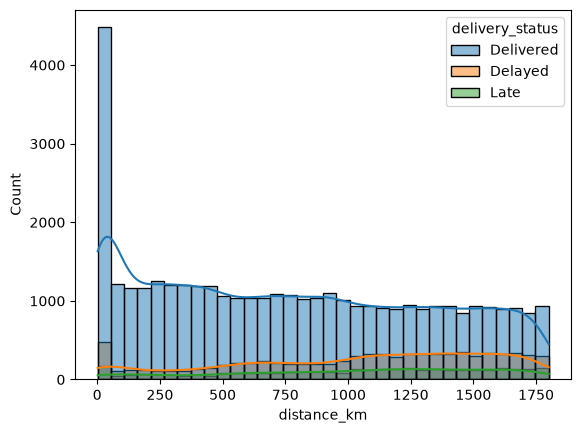

In [20]:
sns.histplot(x=master_df['distance_km'],kde=True,hue=master_df['delivery_status'],multiple='layer')

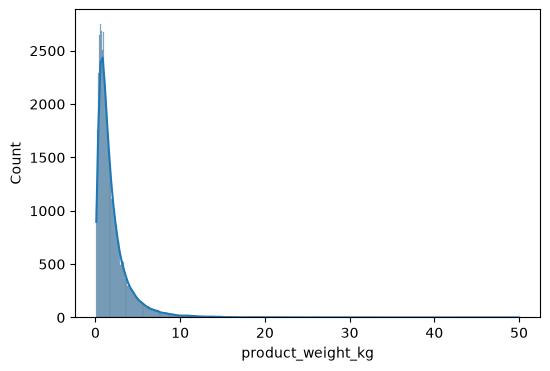

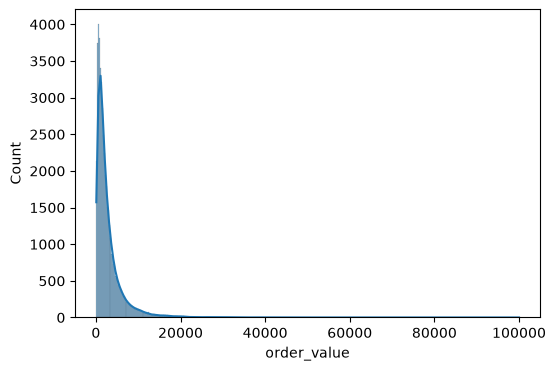

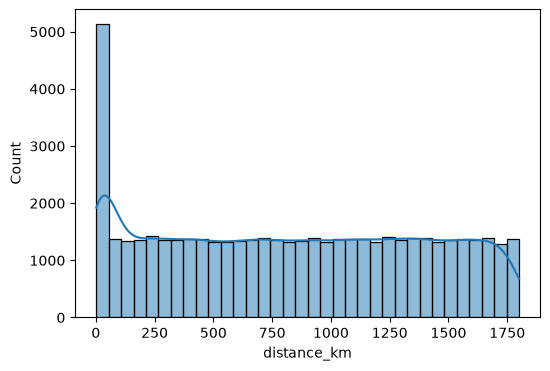

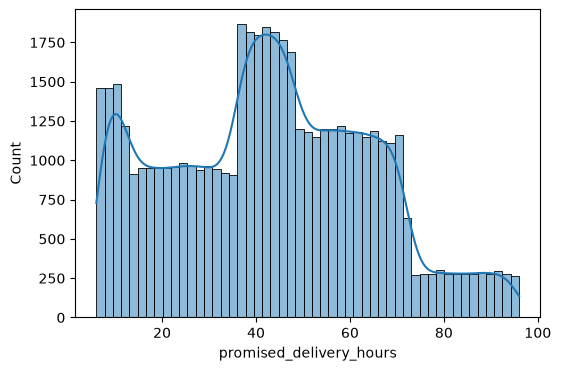

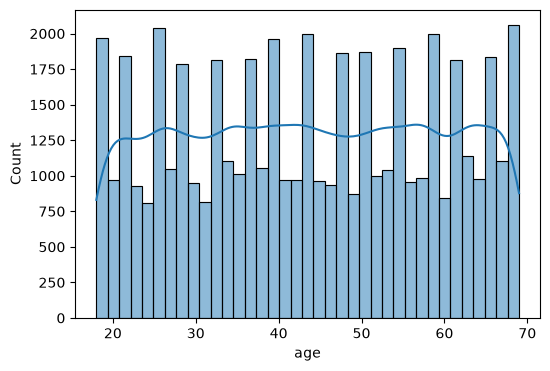

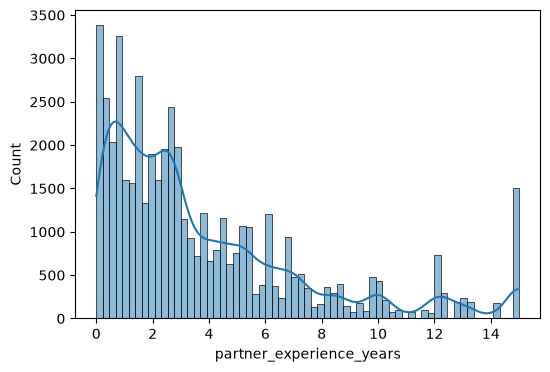

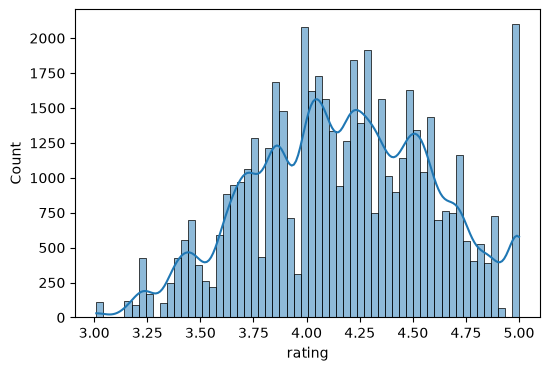

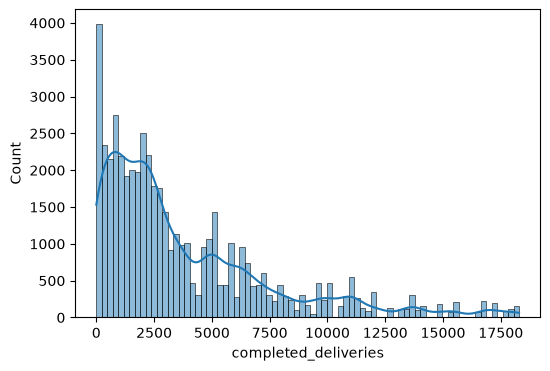

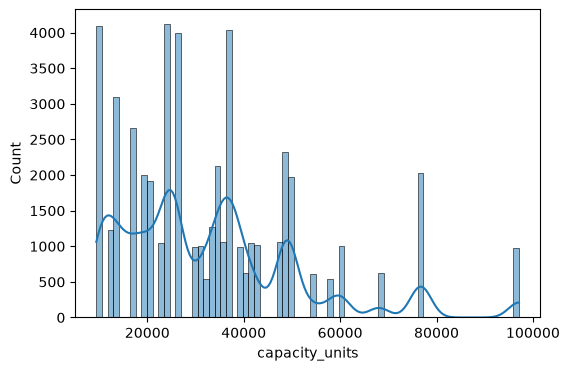

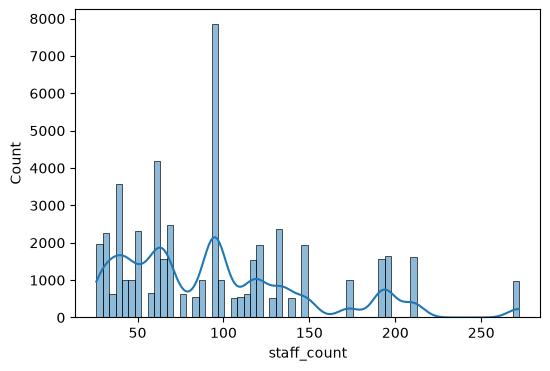

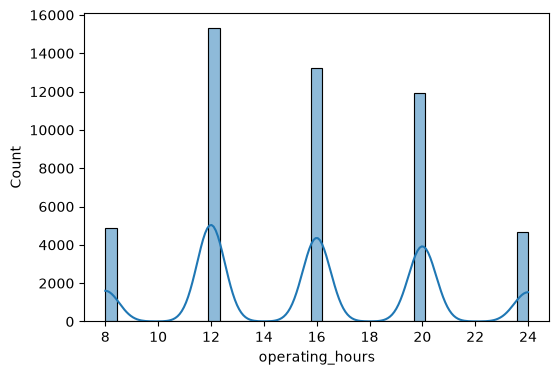

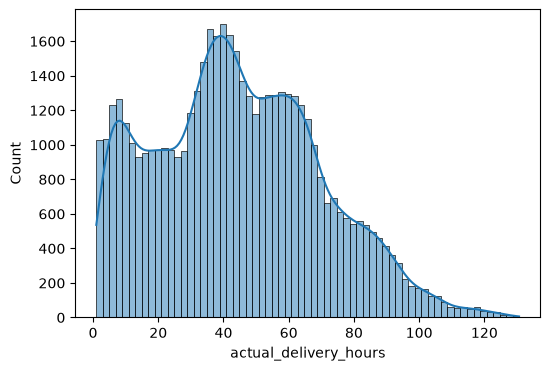

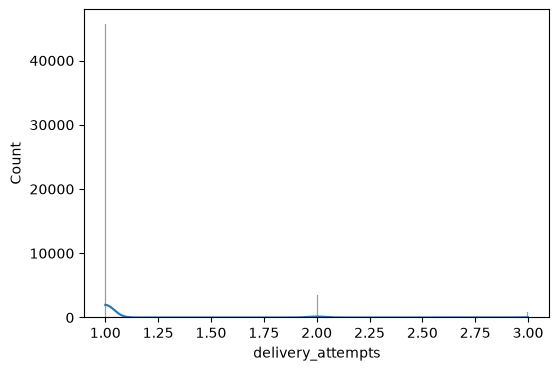

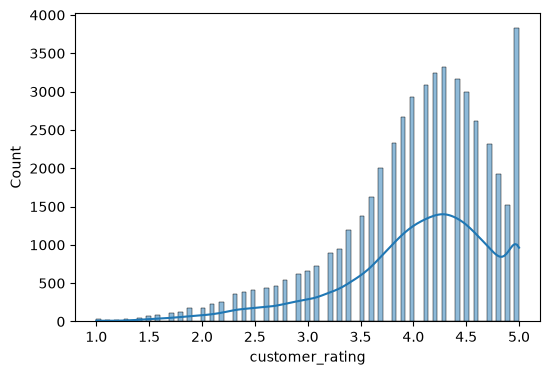

In [21]:
for col in numerical_col:
    plt.figure(figsize=(6,4))
    sns.histplot(data=master_df, x=col,kde = True)
    plt.show()

<Axes: xlabel='product_weight_kg', ylabel='Count'>

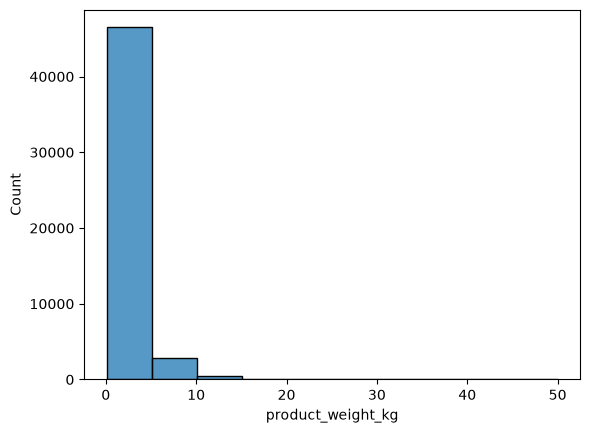

In [22]:
sns.histplot(master_df['product_weight_kg'],bins=10)

Text(0.5, 9.444444444444427, 'Warehouse Capacity')

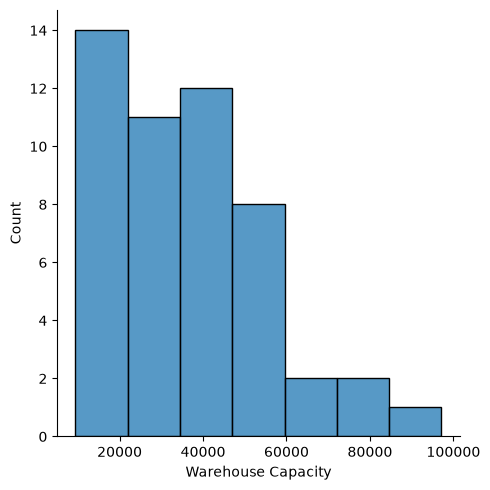

In [23]:
sns.displot(x=warehouse_df['capacity_units'])
plt.xlabel("Warehouse Capacity")

<Axes: xlabel='actual_delivery_hours'>

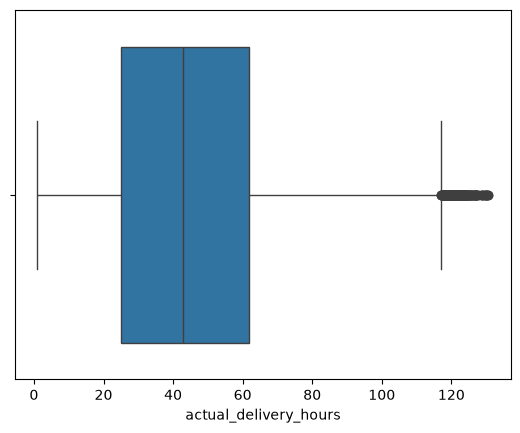

In [24]:
sns.boxplot(x=master_df['actual_delivery_hours'])

<Axes: xlabel='age'>

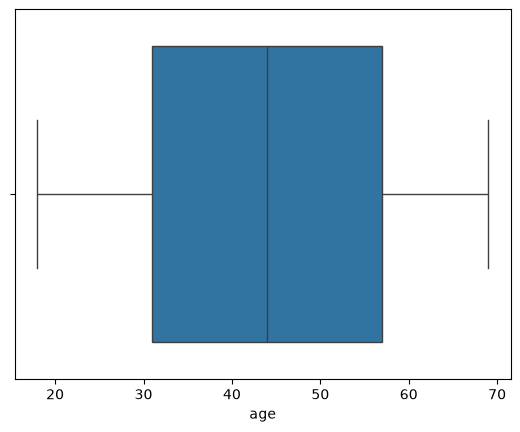

In [25]:
sns.boxplot(x=master_df['age'])

<Axes: xlabel='distance_km'>

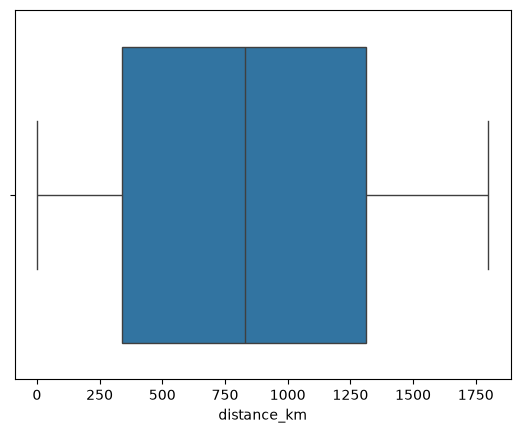

In [26]:
sns.boxplot(x=master_df['distance_km'])

<Axes: xlabel='partner_experience_years'>

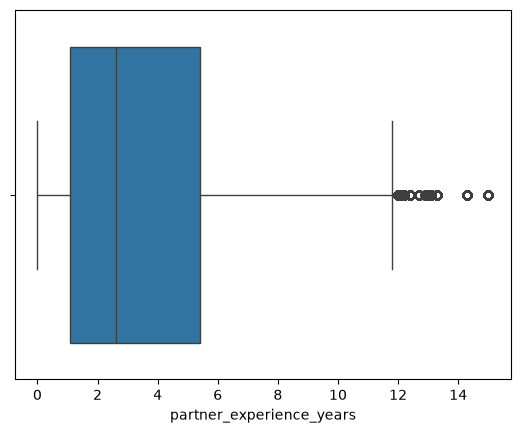

In [27]:
sns.boxplot(x=master_df['partner_experience_years'])

<Axes: xlabel='order_value'>

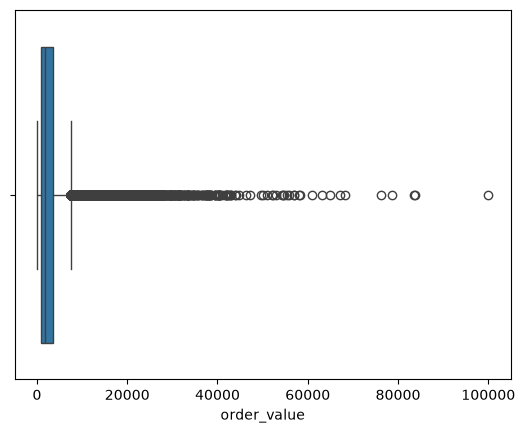

In [28]:
sns.boxplot(x=master_df['order_value'])

## Categorical

<Axes: xlabel='gender', ylabel='count'>

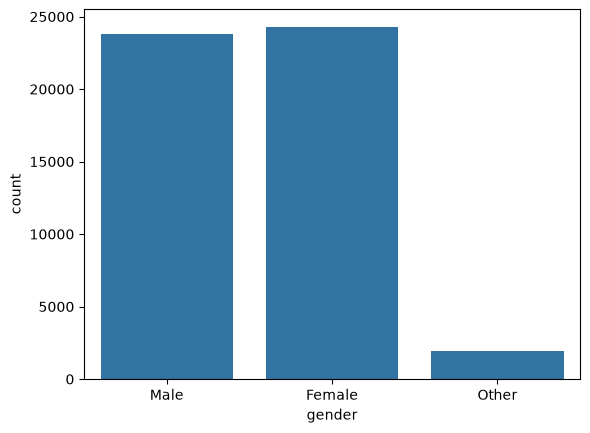

In [29]:
sns.countplot(master_df, x='gender')

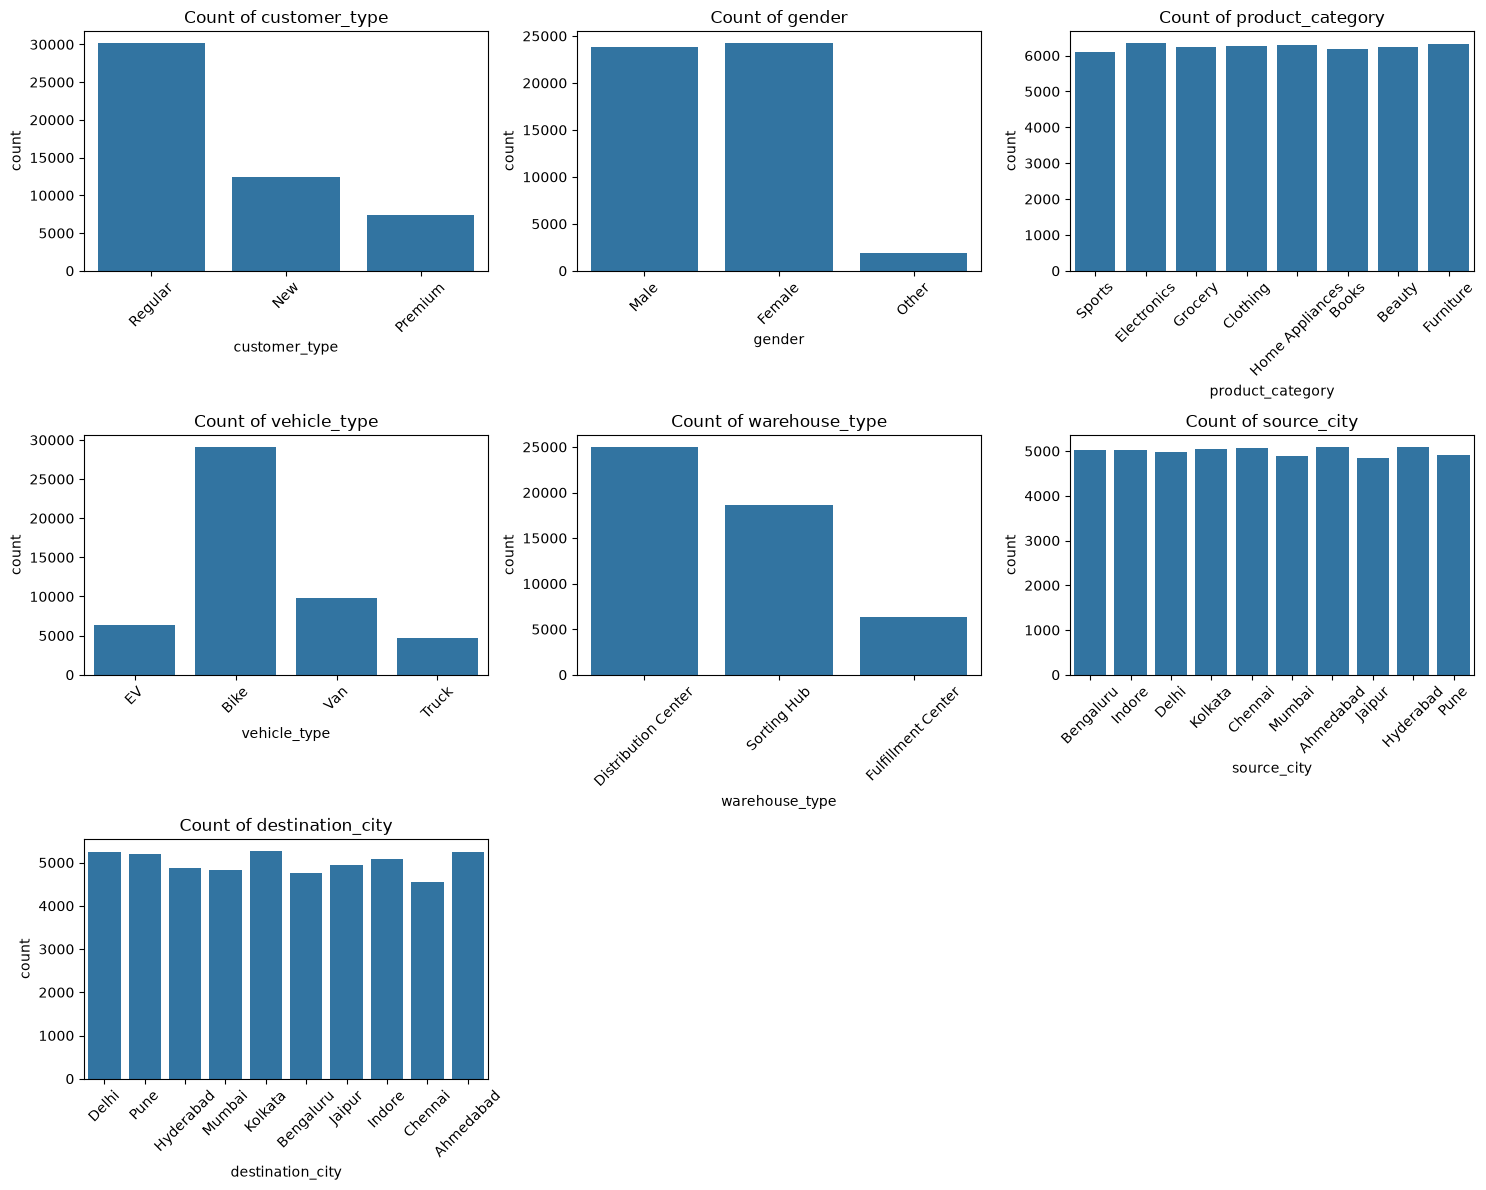

In [30]:
plt.figure(figsize=(15,12))

categorical_col = master_df[[
    'customer_type', 'gender', 'product_category', 'vehicle_type', 'warehouse_type', 'source_city', 'destination_city'
    ]]
for i,col in enumerate(categorical_col, 1):
    plt.subplot(3,3,i)
    sns.countplot(data=master_df, x=col)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()


In [31]:
numerical_col

,product_weight_kg,order_value,distance_km,promised_delivery_hours,age,partner_experience_years,rating,completed_deliveries,capacity_units,staff_count,operating_hours,actual_delivery_hours,delivery_attempts,customer_rating
0,0.90,1437.16,225.62,21.01,61,1.7,4.52,2270,24080,95,16,17.15,1,4.0
1,0.21,340.44,105.94,22.33,64,2.8,3.65,2660,31252,96,16,20.12,1,3.7
2,0.58,12305.73,657.27,36.23,41,1.4,4.28,871,50047,192,16,35.20,1,3.8
3,0.62,4412.42,797.24,33.97,19,1.4,4.66,2168,77103,173,16,34.32,1,4.5
4,1.19,2143.63,844.64,54.02,19,2.0,4.49,2165,60276,211,24,53.06,1,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2.14,1633.81,840.86,42.95,32,10.5,4.25,9912,9755,26,12,42.47,1,4.5
49996,0.94,4445.84,577.36,28.63,50,2.5,4.21,3339,37409,94,20,22.66,1,4.2
49997,0.92,556.10,558.11,44.60,45,1.3,4.13,1565,26183,66,12,37.23,1,5.0
49998,0.48,1901.95,8.18,6.85,55,3.8,3.84,4559,76366,195,24,5.13,1,4.1


In [32]:
master_df.head()

,order_id,customer_id,order_date,order_time,source_city,destination_city,product_category,product_weight_kg,order_value,distance_km,promised_delivery_hours,warehouse_id,partner_id,name,age,gender,city_x,customer_type,signup_date,partner_name,partner_experience_years,vehicle_type,rating,completed_deliveries,partner_city,warehouse_name,city_y,warehouse_type,capacity_units,staff_count,operating_hours,event_id,pickup_time,actual_delivery_hours,delivery_status,delay_reason,delivery_attempts,customer_rating
0,ORD000001,CUST006015,2024-11-25,04:59:28,Bengaluru,Delhi,Sports,0.90,1437.16,225.62,21.01,WH0009,PART0462,Vrinda Roy,61,Male,Delhi,Regular,2025-10-16,Dakshesh Sood,1.7,EV,4.52,2270,Bengaluru,Bengaluru Warehouse 09,Bengaluru,Distribution Center,24080,95,16,EVT000001,04:59:28,17.15,Delivered,NaN,1,4.0
1,ORD000002,CUST004959,2024-04-17,15:41:59,Indore,Delhi,Electronics,0.21,340.44,105.94,22.33,WH0036,PART0275,Vivaan Murty,64,Female,Delhi,Regular,2026-02-19,Manya Krishnamurthy,2.8,Bike,3.65,2660,Indore,Indore Warehouse 36,Indore,Distribution Center,31252,96,16,EVT000002,15:41:59,20.12,Delivered,NaN,1,3.7
2,ORD000003,CUST006266,2025-11-04,23:49:26,Indore,Pune,Sports,0.58,12305.73,657.27,36.23,WH0044,PART0267,Chandran Grewal,41,Female,Pune,Regular,2023-09-10,Janaki Salvi,1.4,EV,4.28,871,Indore,Indore Warehouse 44,Indore,Sorting Hub,50047,192,16,EVT000003,23:49:26,35.20,Delivered,NaN,1,3.8
3,ORD000004,CUST000442,2026-01-12,22:10:34,Indore,Hyderabad,Electronics,0.62,4412.42,797.24,33.97,WH0045,PART0287,Jeevika Pathak,19,Male,Hyderabad,Regular,2024-04-14,Diya Sibal,1.4,Bike,4.66,2168,Indore,Indore Warehouse 45,Indore,Fulfillment Center,77103,173,16,EVT000004,22:10:34,34.32,Delivered,NaN,1,4.5
4,ORD000005,CUST007885,2026-08-01,00:42:35,Delhi,Mumbai,Grocery,1.19,2143.63,844.64,54.02,WH0015,PART0447,Baghyawati Kothari,19,Female,Mumbai,Regular,2024-11-23,Pavani Saraf,2.0,Van,4.49,2165,Delhi,Delhi Warehouse 15,Delhi,Fulfillment Center,60276,211,24,EVT000005,00:42:35,53.06,Delivered,NaN,1,4.8


# Relationships |

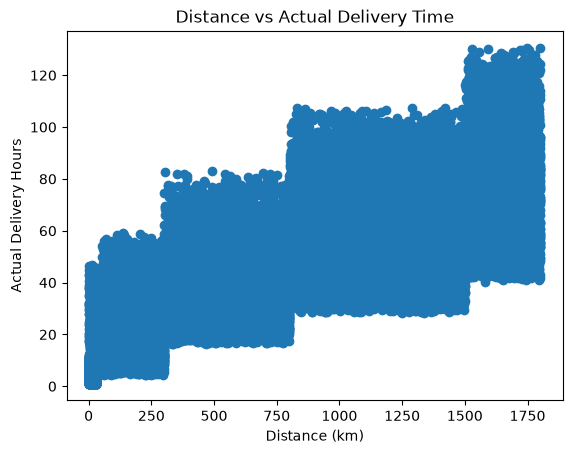

In [33]:
plt.scatter(
    master_df["distance_km"],
    master_df["actual_delivery_hours"]
)

plt.xlabel("Distance (km)")
plt.ylabel("Actual Delivery Hours")
plt.title("Distance vs Actual Delivery Time")

plt.show()

In [34]:
master_df[
    ["promised_delivery_hours", "actual_delivery_hours"]
].corr()

,promised_delivery_hours,actual_delivery_hours
promised_delivery_hours,1.000000,0.904925
actual_delivery_hours,0.904925,1.000000


# Target creation |

In [35]:
master_df[['actual_delivery_hours','promised_delivery_hours']]

,actual_delivery_hours,promised_delivery_hours
0,17.15,21.01
1,20.12,22.33
2,35.20,36.23
3,34.32,33.97
4,53.06,54.02
...,...,...
49995,42.47,42.95
49996,22.66,28.63
49997,37.23,44.60
49998,5.13,6.85


In [36]:
master_df['late_delivery'] = (master_df['actual_delivery_hours']>master_df['promised_delivery_hours']).astype(int)

In [37]:
master_df[['actual_delivery_hours', 'promised_delivery_hours', 'late_delivery']]

,actual_delivery_hours,promised_delivery_hours,late_delivery
0,17.15,21.01,0
1,20.12,22.33,0
2,35.20,36.23,0
3,34.32,33.97,1
4,53.06,54.02,0
...,...,...,...
49995,42.47,42.95,0
49996,22.66,28.63,0
49997,37.23,44.60,0
49998,5.13,6.85,0


In [38]:
master_df['late_delivery'].value_counts().sum

<bound method Series.sum of late_delivery
0    36006
1    13994
Name: count, dtype: int64>

In [39]:
master_df["late_delivery"].value_counts(normalize=True) * 100

late_delivery
0    72.012
1    27.988
Name: proportion, dtype: float64

# Messy Data

In [40]:
messy_df = pd.read_csv('../data/messy/master_messy.csv')

In [41]:
messy_df

,order_id,customer_id,order_date,order_time,source_city,destination_city,product_category,product_weight_kg,order_value,distance_km,promised_delivery_hours,warehouse_id,partner_id,name,age,gender,city_x,customer_type,signup_date,partner_name,partner_experience_years,vehicle_type,rating,completed_deliveries,partner_city,warehouse_name,city_y,warehouse_type,capacity_units,staff_count,operating_hours,event_id,pickup_time,actual_delivery_hours,delivery_status,delay_reason,delivery_attempts,customer_rating
0,ORD000001,CUST006015,2024-11-25,04:59:28,Bengaluru,Delhi,Sports,0.90,1437.16,225.62,21.01,WH0009,PART0462,Vrinda Roy,61.0,Male,Delhi,Regular,2025-10-16,Dakshesh Sood,1.7,EV,4.52,2270,Bengaluru,Bengaluru Warehouse 09,Bengaluru,Distribution Center,24080,95,16,EVT000001,04:59:28,17.15,Delivered,NaN,1,4.0
1,ORD000002,CUST004959,2024-04-17,15:41:59,Indore,Delhi,Electronics,0.21,340.44,105.94,22.33,WH0036,PART0275,Vivaan Murty,64.0,Female,Delhi,Regular,2026-02-19,Manya Krishnamurthy,2.8,Bike,3.65,2660,Indore,Indore Warehouse 36,Indore,Distribution Center,31252,96,16,EVT000002,15:41:59,20.12,Delivered,NaN,1,3.7
2,ORD000003,CUST006266,2025-11-04,23:49:26,Indore,Pune,Sports,0.58,NaN,657.27,36.23,WH0044,PART0267,Chandran Grewal,41.0,Female,Pune,Regular,2023-09-10,Janaki Salvi,1.4,EV,4.28,871,Indore,Indore Warehouse 44,Indore,Sorting Hub,50047,192,16,EVT000003,23:49:26,35.20,Delivered,NaN,1,3.8
3,ORD000004,CUST000442,2026-01-12,22:10:34,Indore,Hyderabad,Electronics,0.62,4412.42,797.24,33.97,WH0045,PART0287,Jeevika Pathak,19.0,Male,Hyderabad,Regular,2024-04-14,Diya Sibal,1.4,Bike,4.66,2168,Indore,Indore Warehouse 45,Indore,Fulfillment Center,77103,173,16,EVT000004,22:10:34,34.32,Delivered,NaN,1,4.5
4,ORD000005,CUST007885,2026-08-01,00:42:35,Delhi,Mumbai,Grocery,1.19,2143.63,844.64,54.02,WH0015,PART0447,Baghyawati Kothari,NaN,Female,Mumbai,Regular,2024-11-23,Pavani Saraf,2.0,Van,4.49,2165,Delhi,Delhi Warehouse 15,Delhi,Fulfillment Center,60276,211,24,EVT000005,00:42:35,53.06,Delivered,NaN,1,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50495,ORD000315,CUST001688,2025-07-22,23:22:48,Pune,Chennai,Furniture,1.61,6959.70,945.28,71.18,WH0030,PART0404,Vedika Thaker,NaN,Female,Chennai,Regular,2024-11-24,Janaki Sarna,6.0,Bike,3.82,8473,Pune,Pune Warehouse 30,Pune,Sorting Hub,37409,94,20,EVT000315,23:22:48,68.02,Delivered,NaN,1,4.1
50496,ORD011450,CUST000668,2026-07-14,05:04:12,Pune,Bengaluru,Electronics,4.77,1128.42,391.66,44.48,WH0030,PART0374,Pranit Bala,NaN,Other,Bengaluru,Regular,2025-10-01,Omisha Gole,2.5,Bike,4.21,3339,Pune,Pune Warehouse 30,Pune,Sorting Hub,37409,94,20,EVT011450,05:04:12,41.33,Delivered,NaN,1,4.0
50497,ORD030746,CUST009815,2025-06-02,15:46:29,Mumbai,Bengaluru,Furniture,1.41,294.07,1519.15,74.68,WH0039,PART0360,Meera Deol,NaN,Female,Bengaluru,Regular,2025-01-10,Yuvraj Mistry,NaN,Bike,4.20,2636,Mumbai,Mumbai Warehouse 39,Mumbai,Sorting Hub,41073,134,20,EVT030746,15:46:29,68.57,Delivered,NaN,1,4.6
50498,ORD029703,CUST001513,2024-04-12,11:28:15,Mumbai,Chennai,Beauty,0.41,2135.63,1308.99,48.20,WH0040,PART0109,William Kohli,NaN,Female,chennai,New,2024-12-27,Lakshit Sami,14.3,Bike,4.46,16717,Mumbai,Mumbai Warehouse 40,Mumbai,Sorting Hub,49593,148,20,EVT029703,11:28:15,40.45,Delivered,NaN,1,4.1


In [42]:
messy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50500 entries, 0 to 50499
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  50500 non-null  object 
 1   customer_id               50500 non-null  object 
 2   order_date                50500 non-null  object 
 3   order_time                50500 non-null  object 
 4   source_city               50500 non-null  object 
 5   destination_city          50500 non-null  object 
 6   product_category          50500 non-null  object 
 7   product_weight_kg         48991 non-null  float64
 8   order_value               48984 non-null  float64
 9   distance_km               50500 non-null  float64
 10  promised_delivery_hours   50500 non-null  float64
 11  warehouse_id              50500 non-null  object 
 12  partner_id                50500 non-null  object 
 13  name                      50500 non-null  object 
 14  age   

In [43]:
messy_df.shape

(50500, 38)

In [44]:
messy_df.size

1919000

In [45]:
messy_df.describe()

,product_weight_kg,order_value,distance_km,promised_delivery_hours,age,partner_experience_years,rating,completed_deliveries,capacity_units,staff_count,operating_hours,actual_delivery_hours,delivery_attempts,customer_rating
count,48991.000000,48984.000000,50500.000000,50500.000000,48503.000000,48982.000000,48987.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000
mean,2.032963,3076.379754,833.444219,42.897644,43.731316,3.827312,4.172602,3845.408198,33232.513921,96.774515,15.696554,44.487691,1.104554,4.023723
std,2.279957,5334.084374,551.815916,21.524147,15.501921,3.677800,0.451732,3835.609383,18737.309330,55.111743,4.560413,25.487801,0.360200,0.725206
min,0.100000,100.000000,2.000000,6.000000,-5.000000,0.000000,0.000000,0.000000,9421.000000,26.000000,8.000000,1.000000,1.000000,1.000000
25%,0.740000,923.042500,338.727500,25.790000,31.000000,1.100000,3.870000,1033.000000,19277.000000,52.000000,12.000000,24.950000,1.000000,3.700000
50%,1.350000,1825.155000,827.365000,42.820000,44.000000,2.600000,4.190000,2498.000000,30114.000000,94.000000,16.000000,42.880000,1.000000,4.100000
75%,2.480000,3557.462500,1313.992500,58.712500,57.000000,5.400000,4.500000,5445.000000,41073.000000,121.000000,20.000000,61.810000,1.000000,4.500000
max,50.000000,512482.800000,1800.000000,96.000000,150.000000,15.000000,7.000000,18288.000000,97115.000000,272.000000,24.000000,130.620000,3.000000,5.000000


In [46]:
messy_df.isnull().sum()

order_id                        0
customer_id                     0
order_date                      0
order_time                      0
source_city                     0
destination_city                0
product_category                0
product_weight_kg            1509
order_value                  1516
distance_km                     0
promised_delivery_hours         0
warehouse_id                    0
partner_id                      0
name                            0
age                          1997
gender                       1515
city_x                          0
customer_type                   0
signup_date                     0
partner_name                    0
partner_experience_years     1518
vehicle_type                    0
rating                       1513
completed_deliveries            0
partner_city                    0
warehouse_name                  0
city_y                          0
warehouse_type               1433
capacity_units                  0
staff_count   

In [47]:
messy_df.isna().sum()

order_id                        0
customer_id                     0
order_date                      0
order_time                      0
source_city                     0
destination_city                0
product_category                0
product_weight_kg            1509
order_value                  1516
distance_km                     0
promised_delivery_hours         0
warehouse_id                    0
partner_id                      0
name                            0
age                          1997
gender                       1515
city_x                          0
customer_type                   0
signup_date                     0
partner_name                    0
partner_experience_years     1518
vehicle_type                    0
rating                       1513
completed_deliveries            0
partner_city                    0
warehouse_name                  0
city_y                          0
warehouse_type               1433
capacity_units                  0
staff_count   

In [48]:
messy_df.duplicated().sum()

np.int64(268)

In [49]:
messy_df.shape[0]

50500

In [50]:
missing_count = messy_df.isnull().sum()
missing_percentage = (missing_count / messy_df.shape[0])*100

In [51]:
missing_percentage

order_id                     0.000000
customer_id                  0.000000
order_date                   0.000000
order_time                   0.000000
source_city                  0.000000
destination_city             0.000000
product_category             0.000000
product_weight_kg            2.988119
order_value                  3.001980
distance_km                  0.000000
promised_delivery_hours      0.000000
warehouse_id                 0.000000
partner_id                   0.000000
name                         0.000000
age                          3.954455
gender                       3.000000
city_x                       0.000000
customer_type                0.000000
signup_date                  0.000000
partner_name                 0.000000
partner_experience_years     3.005941
vehicle_type                 0.000000
rating                       2.996040
completed_deliveries         0.000000
partner_city                 0.000000
warehouse_name               0.000000
city_y      

In [52]:
missing_percentage

order_id                     0.000000
customer_id                  0.000000
order_date                   0.000000
order_time                   0.000000
source_city                  0.000000
destination_city             0.000000
product_category             0.000000
product_weight_kg            2.988119
order_value                  3.001980
distance_km                  0.000000
promised_delivery_hours      0.000000
warehouse_id                 0.000000
partner_id                   0.000000
name                         0.000000
age                          3.954455
gender                       3.000000
city_x                       0.000000
customer_type                0.000000
signup_date                  0.000000
partner_name                 0.000000
partner_experience_years     3.005941
vehicle_type                 0.000000
rating                       2.996040
completed_deliveries         0.000000
partner_city                 0.000000
warehouse_name               0.000000
city_y      

In [53]:
null_data = {"column_name" : missing_percentage.index, "missing_percentage" : missing_percentage.values}
null_optimize = pd.DataFrame(data=null_data)
null_optimize.sort_values(by='missing_percentage', ascending=False)

,column_name,missing_percentage
35,delay_reason,76.487129
14,age,3.954455
20,partner_experience_years,3.005941
8,order_value,3.001980
15,gender,3.000000
22,rating,2.996040
7,product_weight_kg,2.988119
27,warehouse_type,2.837624
5,destination_city,0.000000
4,source_city,0.000000


In [54]:
messy_df.head()

,order_id,customer_id,order_date,order_time,source_city,destination_city,product_category,product_weight_kg,order_value,distance_km,promised_delivery_hours,warehouse_id,partner_id,name,age,gender,city_x,customer_type,signup_date,partner_name,partner_experience_years,vehicle_type,rating,completed_deliveries,partner_city,warehouse_name,city_y,warehouse_type,capacity_units,staff_count,operating_hours,event_id,pickup_time,actual_delivery_hours,delivery_status,delay_reason,delivery_attempts,customer_rating
0,ORD000001,CUST006015,2024-11-25,04:59:28,Bengaluru,Delhi,Sports,0.90,1437.16,225.62,21.01,WH0009,PART0462,Vrinda Roy,61.0,Male,Delhi,Regular,2025-10-16,Dakshesh Sood,1.7,EV,4.52,2270,Bengaluru,Bengaluru Warehouse 09,Bengaluru,Distribution Center,24080,95,16,EVT000001,04:59:28,17.15,Delivered,NaN,1,4.0
1,ORD000002,CUST004959,2024-04-17,15:41:59,Indore,Delhi,Electronics,0.21,340.44,105.94,22.33,WH0036,PART0275,Vivaan Murty,64.0,Female,Delhi,Regular,2026-02-19,Manya Krishnamurthy,2.8,Bike,3.65,2660,Indore,Indore Warehouse 36,Indore,Distribution Center,31252,96,16,EVT000002,15:41:59,20.12,Delivered,NaN,1,3.7
2,ORD000003,CUST006266,2025-11-04,23:49:26,Indore,Pune,Sports,0.58,NaN,657.27,36.23,WH0044,PART0267,Chandran Grewal,41.0,Female,Pune,Regular,2023-09-10,Janaki Salvi,1.4,EV,4.28,871,Indore,Indore Warehouse 44,Indore,Sorting Hub,50047,192,16,EVT000003,23:49:26,35.20,Delivered,NaN,1,3.8
3,ORD000004,CUST000442,2026-01-12,22:10:34,Indore,Hyderabad,Electronics,0.62,4412.42,797.24,33.97,WH0045,PART0287,Jeevika Pathak,19.0,Male,Hyderabad,Regular,2024-04-14,Diya Sibal,1.4,Bike,4.66,2168,Indore,Indore Warehouse 45,Indore,Fulfillment Center,77103,173,16,EVT000004,22:10:34,34.32,Delivered,NaN,1,4.5
4,ORD000005,CUST007885,2026-08-01,00:42:35,Delhi,Mumbai,Grocery,1.19,2143.63,844.64,54.02,WH0015,PART0447,Baghyawati Kothari,NaN,Female,Mumbai,Regular,2024-11-23,Pavani Saraf,2.0,Van,4.49,2165,Delhi,Delhi Warehouse 15,Delhi,Fulfillment Center,60276,211,24,EVT000005,00:42:35,53.06,Delivered,NaN,1,4.8


In [55]:
messy_df.head()

,order_id,customer_id,order_date,order_time,source_city,destination_city,product_category,product_weight_kg,order_value,distance_km,promised_delivery_hours,warehouse_id,partner_id,name,age,gender,city_x,customer_type,signup_date,partner_name,partner_experience_years,vehicle_type,rating,completed_deliveries,partner_city,warehouse_name,city_y,warehouse_type,capacity_units,staff_count,operating_hours,event_id,pickup_time,actual_delivery_hours,delivery_status,delay_reason,delivery_attempts,customer_rating
0,ORD000001,CUST006015,2024-11-25,04:59:28,Bengaluru,Delhi,Sports,0.90,1437.16,225.62,21.01,WH0009,PART0462,Vrinda Roy,61.0,Male,Delhi,Regular,2025-10-16,Dakshesh Sood,1.7,EV,4.52,2270,Bengaluru,Bengaluru Warehouse 09,Bengaluru,Distribution Center,24080,95,16,EVT000001,04:59:28,17.15,Delivered,NaN,1,4.0
1,ORD000002,CUST004959,2024-04-17,15:41:59,Indore,Delhi,Electronics,0.21,340.44,105.94,22.33,WH0036,PART0275,Vivaan Murty,64.0,Female,Delhi,Regular,2026-02-19,Manya Krishnamurthy,2.8,Bike,3.65,2660,Indore,Indore Warehouse 36,Indore,Distribution Center,31252,96,16,EVT000002,15:41:59,20.12,Delivered,NaN,1,3.7
2,ORD000003,CUST006266,2025-11-04,23:49:26,Indore,Pune,Sports,0.58,NaN,657.27,36.23,WH0044,PART0267,Chandran Grewal,41.0,Female,Pune,Regular,2023-09-10,Janaki Salvi,1.4,EV,4.28,871,Indore,Indore Warehouse 44,Indore,Sorting Hub,50047,192,16,EVT000003,23:49:26,35.20,Delivered,NaN,1,3.8
3,ORD000004,CUST000442,2026-01-12,22:10:34,Indore,Hyderabad,Electronics,0.62,4412.42,797.24,33.97,WH0045,PART0287,Jeevika Pathak,19.0,Male,Hyderabad,Regular,2024-04-14,Diya Sibal,1.4,Bike,4.66,2168,Indore,Indore Warehouse 45,Indore,Fulfillment Center,77103,173,16,EVT000004,22:10:34,34.32,Delivered,NaN,1,4.5
4,ORD000005,CUST007885,2026-08-01,00:42:35,Delhi,Mumbai,Grocery,1.19,2143.63,844.64,54.02,WH0015,PART0447,Baghyawati Kothari,NaN,Female,Mumbai,Regular,2024-11-23,Pavani Saraf,2.0,Van,4.49,2165,Delhi,Delhi Warehouse 15,Delhi,Fulfillment Center,60276,211,24,EVT000005,00:42:35,53.06,Delivered,NaN,1,4.8


In [56]:
null_optimize.sort_values(by='missing_percentage', ascending = False)
messy_df[
    ['delay_reason', 'age', 'partner_experience_years','order_value','gender','rating','product_weight_kg','warehouse_type']
    ].isnull().sum()

delay_reason                38626
age                          1997
partner_experience_years     1518
order_value                  1516
gender                       1515
rating                       1513
product_weight_kg            1509
warehouse_type               1433
dtype: int64

In [57]:
messy_df.isnull().sum(axis=1).value_counts().sort_index()

0     9503
1    33097
2     7209
3      654
4       35
5        2
Name: count, dtype: int64

# Data Cleaning


In [59]:
# Numeric - Missing Handle
numerics = messy_df.select_dtypes(include='number')
num_null = {'column_name': numerics.columns, 'missing_count': numerics.isnull().sum(), 'filled_count': (messy_df.shape[0] - numerics.isnull().sum())}
null_numeric = pd.DataFrame(data=num_null)
null_numeric.sort_values(by='missing_count', ascending=False)


<Axes: xlabel='age'>

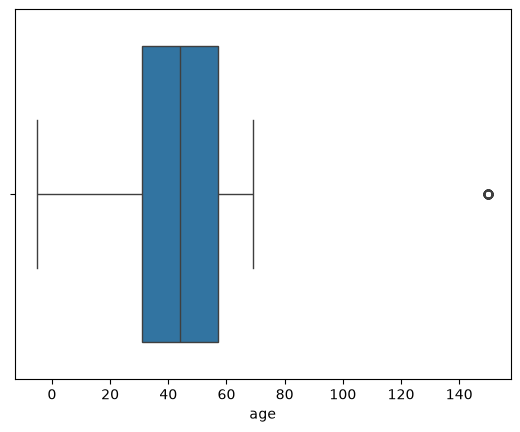

In [60]:
sns.boxplot(x=messy_df['age'])


In [61]:
# Found outlier in age feature | Some ages are greater that 100 i mean that are 150 and it's not possible 

In [ ]:
# Outlier handling using Interquartile in age column
Q1 = messy_df['age'].quantile(0.25)
Q3 = messy_df['age'].quantile(0.75)
print(Q1, Q3)
IQR = Q3-Q1
print(IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound,upper_bound)

In [ ]:
outliers = messy_df[
    (messy_df['age']<lower_bound) | (messy_df['age']>upper_bound)
]
print(outliers)

In [ ]:
messy_df.loc[
    (messy_df['age']<lower_bound) | (messy_df['age']>upper_bound), 'age'
] = np.nan

In [ ]:
messy_df['age'].isna().sum()

In [ ]:
# Age Handling

In [ ]:
messy_df['age'].describe()

In [ ]:
mean_age = messy_df['age'].mean()
mean_age
messy_df['age'] = messy_df['age'].fillna(mean_age)


In [ ]:
messy_df['age'].isnull().sum()
messy_df['age'].astype(int)
messy_df['age'].describe()

In [ ]:
# partner_experience_years
sns.boxplot(x=messy_df['partner_experience_years'])
# Guniune Outliers

In [ ]:
messy_df.describe()
messy_df['partner_experience_years'] = messy_df['partner_experience_years'].fillna(messy_df['partner_experience_years'].mean())

In [ ]:
# order_value
messy_df['order_value'].describe()
med_order_val = messy_df['order_value'].median()
messy_df['order_value'] = messy_df['order_value'].fillna(med_order_val)
messy_df['order_value'].describe()

In [ ]:
# Data Types
numerics = messy_df.select_dtypes(include="number")
categorical = messy_df.drop(columns=numerics)




In [ ]:
null_numeric.sort_values(by='missing_count', ascending=False)


In [ ]:
sns.histplot(x=messy_df['order_value'], kde=True)

In [ ]:
# rating
messy_df['rating'].describe()

In [ ]:
med_rating = messy_df['rating'].median()
med_rating
messy_df['rating'] = messy_df['rating'].fillna(med_rating)

In [ ]:
# product_weight_kg
med_product_weight_kg = messy_df['product_weight_kg'].median()
messy_df['product_weight_kg'] = messy_df['product_weight_kg'].fillna(med_product_weight_kg)

In [ ]:
messy_df['product_weight_kg'].describe()


In [ ]:
sns.boxplot(x=messy_df['product_weight_kg'])

# Categorical Cleaning

In [62]:
categorical_col = messy_df.select_dtypes(include='object')
# messy_df[categorical_col]

In [63]:
cat_null = {"column_name" : categorical_col.columns, "missing_count":categorical_col.isnull().sum(), "filled_count" : (messy_df.shape[0]-categorical_col.isnull().sum())}
null_cat = pd.DataFrame(data=cat_null)
null_cat = null_cat.sort_values(by='missing_count', ascending=False)

In [64]:
categorical_col.isnull().sum()

order_id                0
customer_id             0
order_date              0
order_time              0
source_city             0
destination_city        0
product_category        0
warehouse_id            0
partner_id              0
name                    0
gender               1515
city_x                  0
customer_type           0
signup_date             0
partner_name            0
vehicle_type            0
partner_city            0
warehouse_name          0
city_y                  0
warehouse_type       1433
event_id                0
pickup_time             0
delivery_status         0
delay_reason        38626
dtype: int64

In [ ]:
# There is no profit for filling na in delay reason probability none delay reason means that order was on time

In [65]:
# gender handling (can fill mode because only 3% are missing)
gender_mode = messy_df['gender'].mode().iloc[0]
gender_mode

'Female'

In [66]:
messy_df['gender'] = messy_df['gender'].fillna(gender_mode)

In [67]:
messy_df['gender'].isna().sum()

np.int64(0)

In [68]:
# Warehouse Type

In [69]:
wareh_mode = messy_df['warehouse_type'].mode().iloc[0]
messy_df['warehouse_type'] = messy_df['warehouse_type'].fillna(wareh_mode)
print('Warehouse mode filled:', wareh_mode)


In [70]:
null_cat

,column_name,missing_count,filled_count
delay_reason,delay_reason,38626,11874
gender,gender,1515,48985
warehouse_type,warehouse_type,1433,49067
order_id,order_id,0,50500
source_city,source_city,0,50500
customer_id,customer_id,0,50500
order_date,order_date,0,50500
order_time,order_time,0,50500
warehouse_id,warehouse_id,0,50500
product_category,product_category,0,50500


In [71]:
# Delay Reason
messy_df['delay_reason'].unique()

array([nan, 'Customer Unavailable', 'Operational Delay', 'Traffic',
       'Vehicle Issue', 'Address Issue', 'High Order Volume',
       'Warehouse Delay', 'Weather'], dtype=object)

In [72]:
messy_df[messy_df['delay_reason'] == "nan"]

,order_id,customer_id,order_date,order_time,source_city,destination_city,product_category,product_weight_kg,order_value,distance_km,promised_delivery_hours,warehouse_id,partner_id,name,age,gender,city_x,customer_type,signup_date,partner_name,partner_experience_years,vehicle_type,rating,completed_deliveries,partner_city,warehouse_name,city_y,warehouse_type,capacity_units,staff_count,operating_hours,event_id,pickup_time,actual_delivery_hours,delivery_status,delay_reason,delivery_attempts,customer_rating


<Axes: xlabel='delay_reason'>

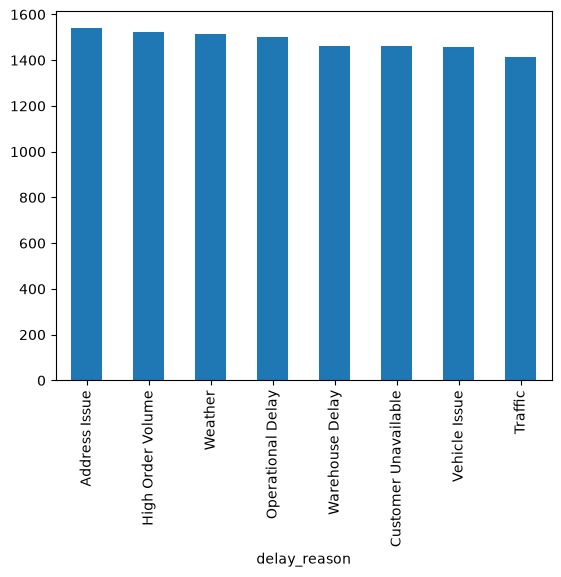

In [73]:
messy_df['delay_reason'].value_counts().plot(kind='bar')

In [74]:
messy_df['delay_reason'].value_counts(dropna=False)

delay_reason
NaN                     38626
Address Issue            1539
High Order Volume        1522
Weather                  1514
Operational Delay        1503
Warehouse Delay          1462
Customer Unavailable     1460
Vehicle Issue            1458
Traffic                  1416
Name: count, dtype: int64

In [75]:
messy_df.columns

Index(['order_id', 'customer_id', 'order_date', 'order_time', 'source_city',
       'destination_city', 'product_category', 'product_weight_kg',
       'order_value', 'distance_km', 'promised_delivery_hours', 'warehouse_id',
       'partner_id', 'name', 'age', 'gender', 'city_x', 'customer_type',
       'signup_date', 'partner_name', 'partner_experience_years',
       'vehicle_type', 'rating', 'completed_deliveries', 'partner_city',
       'warehouse_name', 'city_y', 'warehouse_type', 'capacity_units',
       'staff_count', 'operating_hours', 'event_id', 'pickup_time',
       'actual_delivery_hours', 'delivery_status', 'delay_reason',
       'delivery_attempts', 'customer_rating'],
      dtype='object')

In [76]:
messy_df['late_delivery'] = (
    messy_df['actual_delivery_hours'] > messy_df['promised_delivery_hours']
).astype(int)

print(messy_df['late_delivery'].value_counts())
print(messy_df['late_delivery'].value_counts(normalize=True) * 100)

late_delivery
0    36367
1    14133
Name: count, dtype: int64
late_delivery
0    72.013861
1    27.986139
Name: proportion, dtype: float64


In [77]:
messy_df.head()

,order_id,customer_id,order_date,order_time,source_city,destination_city,product_category,product_weight_kg,order_value,distance_km,promised_delivery_hours,warehouse_id,partner_id,name,age,gender,city_x,customer_type,signup_date,partner_name,partner_experience_years,vehicle_type,rating,completed_deliveries,partner_city,warehouse_name,city_y,warehouse_type,capacity_units,staff_count,operating_hours,event_id,pickup_time,actual_delivery_hours,delivery_status,delay_reason,delivery_attempts,customer_rating,late_delivery
0,ORD000001,CUST006015,2024-11-25,04:59:28,Bengaluru,Delhi,Sports,0.90,1437.16,225.62,21.01,WH0009,PART0462,Vrinda Roy,61.0,Male,Delhi,Regular,2025-10-16,Dakshesh Sood,1.7,EV,4.52,2270,Bengaluru,Bengaluru Warehouse 09,Bengaluru,Distribution Center,24080,95,16,EVT000001,04:59:28,17.15,Delivered,NaN,1,4.0,0
1,ORD000002,CUST004959,2024-04-17,15:41:59,Indore,Delhi,Electronics,0.21,340.44,105.94,22.33,WH0036,PART0275,Vivaan Murty,64.0,Female,Delhi,Regular,2026-02-19,Manya Krishnamurthy,2.8,Bike,3.65,2660,Indore,Indore Warehouse 36,Indore,Distribution Center,31252,96,16,EVT000002,15:41:59,20.12,Delivered,NaN,1,3.7,0
2,ORD000003,CUST006266,2025-11-04,23:49:26,Indore,Pune,Sports,0.58,NaN,657.27,36.23,WH0044,PART0267,Chandran Grewal,41.0,Female,Pune,Regular,2023-09-10,Janaki Salvi,1.4,EV,4.28,871,Indore,Indore Warehouse 44,Indore,Sorting Hub,50047,192,16,EVT000003,23:49:26,35.20,Delivered,NaN,1,3.8,0
3,ORD000004,CUST000442,2026-01-12,22:10:34,Indore,Hyderabad,Electronics,0.62,4412.42,797.24,33.97,WH0045,PART0287,Jeevika Pathak,19.0,Male,Hyderabad,Regular,2024-04-14,Diya Sibal,1.4,Bike,4.66,2168,Indore,Indore Warehouse 45,Indore,Fulfillment Center,77103,173,16,EVT000004,22:10:34,34.32,Delivered,NaN,1,4.5,1
4,ORD000005,CUST007885,2026-08-01,00:42:35,Delhi,Mumbai,Grocery,1.19,2143.63,844.64,54.02,WH0015,PART0447,Baghyawati Kothari,NaN,Female,Mumbai,Regular,2024-11-23,Pavani Saraf,2.0,Van,4.49,2165,Delhi,Delhi Warehouse 15,Delhi,Fulfillment Center,60276,211,24,EVT000005,00:42:35,53.06,Delivered,NaN,1,4.8,0


# currently
late_delivery
0    36367
1    14133
Name: count, dtype: int64
late_delivery
0    72.013861
1    27.986139
Name: proportion, dtype: float64

so this is type of binary classification problem
## my models will use this models to learn 
Distance              = 850 km,
Product weight        = 8 kg,
Promised time         = 30 hours,
Warehouse type        = Regional,
Vehicle type          = Truck,
Partner experience    = 1.2 years,
Partner rating        = 3.1,
Product category      = Electronics,
Delivery attempts     = ?

# Verifying relationships between target and features

In [78]:
messy_df.groupby('vehicle_type')['late_delivery'].mean()*100

vehicle_type
 Bike      28.282123
 EV        28.888889
 Truck     29.864253
 Van       27.343750
Bike       27.547776
EV         28.859390
Truck      31.096346
Van        27.138738
Name: late_delivery, dtype: float64

In [79]:
messy_df['vehicle_type'] = messy_df['vehicle_type'].str.strip()


In [80]:
messy_df['vehicle_type'].unique()

array([<bound method StringMethods.strip of <pandas.core.strings.accessor.StringMethods object at 0x000002C210172F60>>],
      dtype=object)

In [81]:
messy_df['vehicle_type'].isna().sum()

np.int64(0)

In [82]:
master_df['vehicle_type'].unique()

array(['EV', 'Bike', 'Van', 'Truck'], dtype=object)

In [83]:
master_df['vehicle_type'].isna().sum()

np.int64(0)

In [84]:
print(master_df.shape)
print(messy_df.shape)

print(master_df[['order_id', 'vehicle_type']].head())
print(messy_df[['order_id', 'vehicle_type']].head())

(50000, 39)
(50500, 39)
    order_id vehicle_type
0  ORD000001           EV
1  ORD000002         Bike
2  ORD000003           EV
3  ORD000004         Bike
4  ORD000005          Van
    order_id                                       vehicle_type
0  ORD000001  <bound method StringMethods.strip of <pandas.c...
1  ORD000002  <bound method StringMethods.strip of <pandas.c...
2  ORD000003  <bound method StringMethods.strip of <pandas.c...
3  ORD000004  <bound method StringMethods.strip of <pandas.c...
4  ORD000005  <bound method StringMethods.strip of <pandas.c...


In [85]:
vehicle_map = master_df.set_index('order_id')['vehicle_type']

messy_df['vehicle_type'] = messy_df['order_id'].map(vehicle_map)

In [86]:
messy_df['vehicle_type'].unique()

array(['EV', 'Bike', 'Van', 'Truck'], dtype=object)

In [87]:
messy_df['vehicle_type'].isna().sum()

np.int64(0)

In [88]:
messy_df[messy_df['vehicle_type'].isna()][['order_id', 'vehicle_type']].head(10)

,order_id,vehicle_type


In [89]:
messy_df[messy_df['vehicle_type'].isna()]['order_id'].head(10)

Series([], Name: order_id, dtype: object)

In [90]:
messy_df['order_id'].duplicated().sum()

np.int64(500)

In [91]:
duplicate_orders = messy_df[
    messy_df['order_id'].duplicated(keep=False)
].sort_values('order_id')

duplicate_orders[['order_id', 'vehicle_type', 'actual_delivery_hours', 'delay_reason']].head(20)

,order_id,vehicle_type,actual_delivery_hours,delay_reason
147,ORD000148,Bike,20.00,NaN
50279,ORD000148,Bike,20.00,NaN
199,ORD000200,Bike,42.80,NaN
50002,ORD000200,Bike,42.80,NaN
50319,ORD000263,Bike,31.40,NaN
262,ORD000263,Bike,31.40,NaN
50175,ORD000293,Bike,71.99,Customer Unavailable
292,ORD000293,Bike,71.99,Customer Unavailable
314,ORD000315,Bike,68.02,NaN
50495,ORD000315,Bike,68.02,NaN


In [92]:
duplicate_orders['order_id'].nunique()

500

In [93]:
messy_df.duplicated().sum()

np.int64(268)

In [94]:
dup_orders = messy_df[
    messy_df['order_id'].duplicated(keep=False)
].sort_values('order_id')

print(dup_orders.shape)

(1000, 39)


In [95]:
dup_orders[['order_id', 'vehicle_type', 'actual_delivery_hours',
            'delivery_status', 'late_delivery']].head(20)

,order_id,vehicle_type,actual_delivery_hours,delivery_status,late_delivery
147,ORD000148,Bike,20.00,Delivered,0
50279,ORD000148,Bike,20.00,Delivered,0
199,ORD000200,Bike,42.80,Delivered,0
50002,ORD000200,Bike,42.80,Delivered,0
50319,ORD000263,Bike,31.40,Delivered,0
262,ORD000263,Bike,31.40,Delivered,0
50175,ORD000293,Bike,71.99,Late,1
292,ORD000293,Bike,71.99,Late,1
314,ORD000315,Bike,68.02,Delivered,0
50495,ORD000315,Bike,68.02,Delivered,0


In [96]:
print(dup_orders.shape)
print(dup_orders['order_id'].nunique())
print(dup_orders.groupby('order_id')['late_delivery'].nunique().value_counts())

(1000, 39)
500
late_delivery
1    500
Name: count, dtype: int64


In [97]:
dup_check = dup_orders.groupby('order_id').nunique()

print(dup_check.max().sort_values(ascending=False).head(20))

product_category     2
city_x               2
warehouse_type       2
gender               2
rating               2
customer_id          1
destination_city     1
source_city          1
order_time           1
order_date           1
warehouse_id         1
order_value          1
distance_km          1
product_weight_kg    1
age                  1
name                 1
partner_id           1
customer_type        1
signup_date          1
partner_name         1
dtype: int64


In [98]:
for order_id, group in dup_orders.groupby('order_id'):
    if not group.drop(columns=['order_id']).duplicated().all():
        print("Order ID:", order_id)
        print(group.T)
        break

Order ID: ORD000148
                                         147                  50279
order_id                             ORD000148            ORD000148
customer_id                         CUST001760           CUST001760
order_date                          2026-08-10           2026-08-10
order_time                            06:07:28             06:07:28
source_city                             Indore               Indore
destination_city                          Pune                 Pune
product_category                        Books                 Books
product_weight_kg                         2.25                 2.25
order_value                             464.52               464.52
distance_km                             278.95               278.95
promised_delivery_hours                  23.66                23.66
warehouse_id                            WH0037               WH0037
partner_id                            PART0209             PART0209
name                        

In [99]:
check_cols = [
    'product_category',
    'warehouse_type',
    'gender',
    'city_x',
    'rating',
    'age'
]

for col in check_cols:
    print(f"\n{col}:")
    print(dup_orders.groupby('order_id')[col].nunique().value_counts())


product_category:
product_category
1    385
2    115
Name: count, dtype: int64

warehouse_type:
warehouse_type
1    385
2    115
Name: count, dtype: int64

gender:
gender
1    408
2     92
Name: count, dtype: int64

city_x:
city_x
1    435
2     65
Name: count, dtype: int64

rating:
rating
1    483
0     14
2      3
Name: count, dtype: int64

age:
age
0    499
1      1
Name: count, dtype: int64


In [100]:

cat_cols = messy_df.select_dtypes(include='object').columns

for col in cat_cols:
    messy_df[col] = messy_df[col].str.strip().str.lower()

In [101]:
normalize_cols = [
    'product_category',
    'warehouse_type',
    'gender',
    'city_x',
    'source_city',
    'destination_city',
    'customer_type',
    'partner_city',
    'city_y',
    'vehicle_type',
    'delivery_status',
    'delay_reason'
]

for col in normalize_cols:
    messy_df[col] = messy_df[col].str.strip().str.lower()

In [102]:
print(messy_df.duplicated().sum())

493


In [103]:
messy_df = messy_df.drop_duplicates().copy()

print(messy_df.shape)

(50007, 39)


In [104]:
remaining_dups = messy_df[
    messy_df['order_id'].duplicated(keep=False)
].sort_values('order_id')

print(remaining_dups.shape)
print(remaining_dups['order_id'].nunique())

(14, 39)
7


In [105]:
for order_id, group in remaining_dups.groupby('order_id'):
    print("\nORDER:", order_id)
    print(group.T)


ORDER: ord006021
                                           6020                    50159
order_id                               ord006021               ord006021
customer_id                           cust007392              cust007392
order_date                            2025-06-18              2025-06-18
order_time                              05:08:35                05:08:35
source_city                            bengaluru               bengaluru
destination_city                       hyderabad               hyderabad
product_category                       furniture               furniture
product_weight_kg                           0.32                    0.32
order_value                              3506.63                 3506.63
distance_km                               581.55                  581.55
promised_delivery_hours                    36.05                   36.05
warehouse_id                              wh0009                  wh0009
partner_id                       

In [106]:
print(messy_df['order_id'].duplicated().sum())

7


In [107]:
messy_df = messy_df.drop_duplicates(subset='order_id', keep='first').copy()

In [108]:
print(messy_df.shape)
print(messy_df['order_id'].duplicated().sum())
print(messy_df['order_id'].nunique())

(50000, 39)
0
50000


In [109]:
missing = messy_df.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))


delay_reason                38242
product_weight_kg            1500
order_value                  1500
partner_experience_years     1500
rating                       1499
age                          1498
dtype: int64


In [110]:
print("Negative age:", (messy_df['age'] < 0).sum())
print("Invalid rating:", (messy_df['rating'] < 0).sum())
print("Rating > 5:", (messy_df['rating'] > 5).sum())
print("Negative distance:", (messy_df['distance_km'] < 0).sum())
print("Negative weight:", (messy_df['product_weight_kg'] < 0).sum())
print("Negative order value:", (messy_df['order_value'] < 0).sum())
print(messy_df['late_delivery'].value_counts())
print(messy_df['late_delivery'].value_counts(normalize=True) * 100)

Negative age: 49
Invalid rating: 0
Rating > 5: 50
Negative distance: 0
Negative weight: 0
Negative order value: 0
late_delivery
0    36006
1    13994
Name: count, dtype: int64
late_delivery
0    72.012
1    27.988
Name: proportion, dtype: float64


In [111]:
messy_df['rating'].describe()

count    48501.000000
mean         4.172338
std          0.451612
min          0.000000
25%          3.870000
50%          4.190000
75%          4.490000
max          7.000000
Name: rating, dtype: float64

In [113]:
messy_df[messy_df['rating'] > 5][
    ['order_id','partner_id','rating']
].head(20)

,order_id,partner_id,rating
958,ord000959,part0047,7.0
1106,ord001107,part0386,7.0
1453,ord001454,part0240,7.0
1464,ord001465,part0046,7.0
2135,ord002136,part0117,7.0
4290,ord004291,part0126,7.0
6020,ord006021,part0250,7.0
6113,ord006114,part0141,7.0
6415,ord006416,part0438,7.0
7734,ord007735,part0254,7.0


In [114]:
invalid_rating = messy_df[messy_df['rating'] > 5]

In [115]:

print(
    messy_df[
        messy_df['partner_id'].isin(invalid_rating['partner_id'])
        & (messy_df['rating'] <= 5)
    ][['partner_id', 'rating']].head(30)
)

    partner_id  rating
92    part0139    4.40
97    part0184    4.21
101   part0184    4.21
103   part0047    4.46
110   part0303    4.47
115   part0139    4.40
117   part0179    4.08
119   part0179    4.08
121   part0047    4.46
123   part0250    4.88
124   part0168    3.73
134   part0047    4.46
140   part0009    4.02
164   part0342    3.59
175   part0184    4.21
194   part0046    3.90
195   part0342    3.59
196   part0163    3.78
202   part0254    3.83
209   part0401    3.91
211   part0401    3.91
224   part0074    3.77
229   part0139    4.40
230   part0366    4.25
233   part0187    4.21
236   part0256    4.51
249   part0074    3.77
251   part0093    4.59
254   part0236    4.02
265   part0019    3.87


In [117]:
print(messy_df['rating'].describe())

count    48501.000000
mean         4.172338
std          0.451612
min          0.000000
25%          3.870000
50%          4.190000
75%          4.490000
max          7.000000
Name: rating, dtype: float64


In [118]:
messy_df.loc[messy_df['rating'] > 5, 'rating'] = messy_df['rating'].median()

In [119]:
print("Rating > 5:", (messy_df['rating'] > 5).sum())
print(messy_df['rating'].describe())

Rating > 5: 0
count    48501.000000
mean         4.169441
std          0.442383
min          0.000000
25%          3.870000
50%          4.190000
75%          4.490000
max          5.000000
Name: rating, dtype: float64


In [120]:
print((messy_df['rating'] == 0).sum())

49


In [121]:
messy_df.loc[
    (messy_df['rating'] == 0) | (messy_df['rating'] > 5),
    'rating'
] = np.nan

In [122]:
messy_df['rating'] = messy_df['rating'].fillna(messy_df['rating'].median())

In [123]:
print("Rating < 0:", (messy_df['rating'] < 0).sum())
print("Rating > 5:", (messy_df['rating'] > 5).sum())
print("Rating == 0:", (messy_df['rating'] == 0).sum())
print(messy_df['rating'].describe())

Rating < 0: 0
Rating > 5: 0
Rating == 0: 0
count    50000.000000
mean         4.174164
std          0.415679
min          3.010000
25%          3.880000
50%          4.190000
75%          4.480000
max          5.000000
Name: rating, dtype: float64


In [124]:
print(messy_df.shape)
print(messy_df.isnull().sum().sort_values(ascending=False).head(10))

(50000, 39)
delay_reason                38242
product_weight_kg            1500
partner_experience_years     1500
order_value                  1500
age                          1498
customer_id                     0
order_id                        0
product_category                0
destination_city                0
source_city                     0
dtype: int64


In [125]:
messy_df['product_weight_kg'] = messy_df['product_weight_kg'].fillna(
    messy_df['product_weight_kg'].median()
)

In [126]:
messy_df['partner_experience_years'] = messy_df[
    'partner_experience_years'
].fillna(
    messy_df['partner_experience_years'].median()
)

In [127]:
messy_df['order_value'] = messy_df['order_value'].fillna(
    messy_df['order_value'].median()
)

In [128]:
for col in ['product_weight_kg', 'partner_experience_years', 'order_value']:
    messy_df[col] = messy_df[col].fillna(messy_df[col].median())
messy_df['warehouse_type'] = messy_df['warehouse_type'].fillna(messy_df['warehouse_type'].mode().iloc[0])


In [129]:
print(messy_df[['product_weight_kg',
                'partner_experience_years',
                'order_value']].isnull().sum())

product_weight_kg           0
partner_experience_years    0
order_value                 0
dtype: int64


In [130]:
# So finally mera eda hogya abhi we will create a new notebook for machine learning because yehy notebook bhot messy hogyi

In [131]:
messy_df.to_csv('delivery_cleaned.csv', index=False)

In [136]:
import os
os.path.exists("delivery_cleaned.csv")
os.getcwd()

'C:\\Users\\DELL-7280\\OneDrive\\Desktop\\DAta using python\\Machine Learning\\Delivery Prediction\\Notebooks'

In [134]:
print(messy_df.shape)
print("Duplicate order_id:", messy_df['order_id'].duplicated().sum())

(50000, 39)
Duplicate order_id: 0
